In [1]:
import pandas as pd
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt
from graphviz import Digraph

In [2]:
df = pd.read_csv("../data/lightcurve_data.csv")
df

,#oid,period,num_peaks,classALeRCE,time,flux
0,ZTF17aaajgxv,0.572800,51,RRL,"[-0.49942539630433186,-0.49918716586016976,-0....","[16.2058,16.230549,16.24141,16.228073,16.25341..."
1,ZTF17aaarvft,0.197982,66,E,"[-0.49831909833542476,-0.4950773002986282,-0.4...","[12.872672,12.940971,12.945449,12.873761,12.93..."
2,ZTF17aaawecj,0.141549,103,E,"[-0.4996000632531625,-0.4980442585526325,-0.49...","[13.562298,13.590104,13.516534,13.565137,13.53..."
3,ZTF17aabtkpv,0.107327,15260,E,"[-0.47071936453611307,-0.4532932862046125,-0.4...","[16.139889,16.067142,16.121937,16.076378,16.14..."
4,ZTF18aaaizue,0.144033,9377,E,"[-0.3001003371370297,-0.15528214925408973,-0.1...","[15.642073,15.522387,15.527321,15.503612,15.50..."
...,...,...,...,...,...,...
24117,ZTF18aagtegs,1.585586,16177,RRL,"[-0.2745796755985033,-0.25674274157658544,-0.2...","[14.399929,14.242908,14.279523,14.247854,14.29..."
24118,ZTF18aaiyukf,0.510409,3840,RRL,"[-0.4617179422863674,-0.3865598430620424,-0.37...","[16.29467,16.34544,16.29759,16.27945,16.321072..."
24119,ZTF18aapaquz,0.405867,249,RRL,"[-0.499787603836453,-0.4992437168799542,-0.498...","[14.645777,14.654092,14.665266,14.652166,14.74..."
24120,ZTF18aavzlgs,1.009966,3975,LPV,"[-0.4355251277636508,-0.4350795681273988,-0.42...","[15.880947,15.856993,15.8699465,15.646793,15.6..."


In [2]:
df2 = pd.read_csv("../../Data/data_cleaned/data_cleaned.csv")
df2

,#oid,objectid,hmjd,mag,classALeRCE
0,ZTF17aaajgxv,468108300000265,"[58202.25996,58207.26703,58207.29122,58210.268...","[16.176182,16.727537,16.464394,16.164494,16.20...",RRL
1,ZTF17aaarvft,775106100014940,"[58269.47823,58275.46879,58277.46092,58279.464...","[13.324311,13.085313,13.0501995,13.046435,13.0...",E
2,ZTF17aaawecj,1730102300011405,"[58307.47822,58307.47868,58315.43863,58315.439...","[14.009348,14.020831,13.979975,13.967841,14.19...",E
3,ZTF17aabtkpv,1564104300000588,"[58430.40911,58439.46743,58482.5189,58562.2315...","[17.06087,17.001083,17.079542,17.006544,17.008...",E
4,ZTF18aaaizue,1569115400002014,"[58439.50081,58482.52195,58493.55845,58511.476...","[16.126945,16.601835,16.030006,16.553242,16.54...",E
...,...,...,...,...,...
24299,ZTF18aaiyukf,724106100007973,"[58203.49941,58203.50036,58204.40918,58204.436...","[15.466788,15.445214,16.619415,16.560726,16.61...",RRL
24300,ZTF18aapaquz,765105400001822,"[58203.37377,58204.42935,58204.4756,58204.4822...","[15.066149,14.701283,14.711236,14.717887,14.82...",RRL
24301,ZTF18aavzlgs,1727101200027154,"[58242.49268,58274.43757,58274.43802,58323.371...","[18.509867,18.441212,18.397453,18.578817,18.52...",LPV
24302,ZTF18abapzhj,1539114100009582,"[58301.43501,58304.46021,58304.46066,58333.421...","[17.221989,17.280823,17.256195,17.237534,17.21...",E


In [3]:
df_cleaned = df2.head(30)
df_cleaned = df_cleaned.reset_index(drop=True)
df_cleaned_filtered = df_cleaned[['#oid', 'hmjd', 'mag']]
df_cleaned_filtered.to_csv('./test.csv', index=False)

In [3]:
df['classALeRCE'].value_counts()

classALeRCE
E                 7446
RRL               6364
QSO               5195
LPV               2606
AGN                952
YSO                328
Blazar             263
SNIa               243
Periodic-Other     218
CV/Nova            170
DSCT               146
CEP                115
SNII                51
SNIbc               19
SLSN                 6
Name: count, dtype: int64

In [4]:
print(f"time:{df['time'][0]}")

time:[-0.49942539630433186,-0.49918716586016976,-0.4987067408479449,-0.4975081905319123,-0.49497051193727165,-0.49494484556932994,-0.49211156107451254,-0.4920222791172732,-0.49147606612040534,-0.49075590581264195,-0.4907025252790924,-0.4898326791172644,-0.4891497959219316,-0.4864427468868376,-0.4858994872444308,-0.485712565587516,-0.4855245918381073,-0.4850946143183011,-0.4815749939431043,-0.48129773823698313,-0.48113870943196785,-0.4800468316341113,-0.4774548804133558,-0.47331730876894423,-0.4717542302444752,-0.4702558921784856,-0.463444170740778,-0.46208549754963957,-0.46167597804288435,-0.4576922373473059,-0.4551341112370808,-0.4538801866923705,-0.44943455218609285,-0.4468415098600906,-0.44572725017728454,-0.44531443864339737,-0.44505373846040214,-0.4411594088978717,-0.43753939743407644,-0.4349873898131394,-0.4348879681862067,-0.43311036498363575,-0.4326748899599237,-0.43108620211029886,-0.4309456166154393,-0.42716129815629533,-0.4264852911178505,-0.4256329030575881,-0.4179831924353

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24122 entries, 0 to 24121
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   #oid         24122 non-null  object 
 1   period       24122 non-null  float64
 2   num_peaks    24122 non-null  int64  
 3   classALeRCE  24122 non-null  object 
 4   time         24122 non-null  object 
 5   flux         24122 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.1+ MB


<Axes: title={'center': '变星种类的分布'}, xlabel='classALeRCE'>

D:\Anaconda\anaconda3\envs\DeepLearning\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Anaconda\anaconda3\envs\DeepLearning\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Anaconda\anaconda3\envs\DeepLearning\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Anaconda\anaconda3\envs\DeepLearning\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\Anaconda\anaconda3\envs\DeepLearning\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

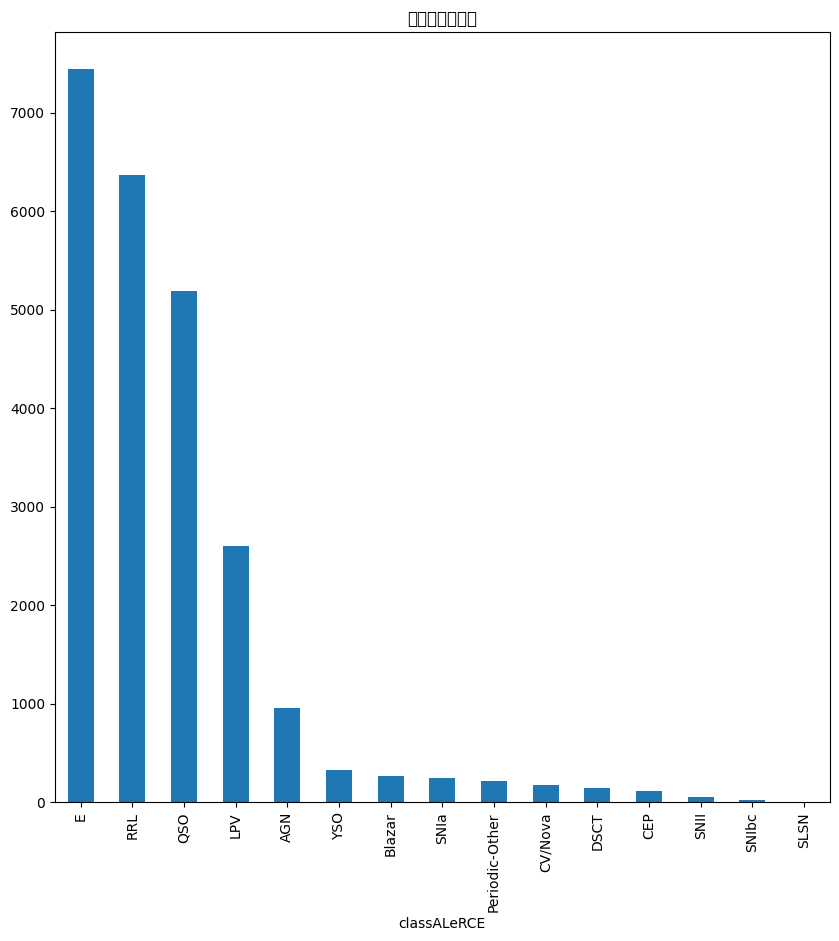

In [3]:
plt.figure(figsize=(10, 10))
plt.title('变星种类的分布')
df['classALeRCE'].value_counts().plot(kind='bar')

In [10]:
with open('lightcurve_data.csv', 'w', newline='') as csv_file:
    writer = csv.writer(csv_file)
    # 写入 CSV 文件的列名
    writer.writerow(['#oid', 'period', 'num_peaks', 'classALeRCE', 'time', 'flux'])

    for i in range(len(df)):
        time = np.array(df['hmjd'][i].strip('[]').split(','), dtype=float)
        flux = np.array(df['mag'][i].strip('[]').split(','), dtype=float)

        # 进行 Lomb - Scargle 周期搜索，限制周期范围 
        lc = lk.LightCurve(time=time, flux=flux)
        pg = lc.to_periodogram(method='lombscargle', minimum_frequency=0.1, maximum_frequency=24)
        peri_arr = pg.period
        period_at_max_power = pg.period_at_max_power
        period = period_at_max_power.value

        # 折叠光变曲线
        folded_lc = lc.fold(period)
        tim, flx = folded_lc.time.value, folded_lc.flux

        # 直接计算相位，避免多次复制数组
        phase = tim / period
        phase_extended = np.concatenate([phase, phase + 1, phase + 2])
        flux_extended = np.tile(flx, 3)

        # 峰值数量特征
        peaks = pg.power > (0.5 * pg.max_power)
        num_peaks = np.sum(peaks)

        # 将 phase_extended 和 flux_extended 转换为字符串，并添加方括号
        phase_str = '[' + ','.join(map(str, phase_extended)) + ']'
        flux_str = '[' + ','.join(map(str, flux_extended)) + ']'

        # 逐行写入 CSV 文件
        writer.writerow([df['#oid'][i], period, num_peaks, df['classALeRCE'][i], phase_str, flux_str])

d:\Anaconda\anaconda3\envs\DeepLearning\lib\site-packages\astropy\units\quantity.py:671: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [4]:
time = np.array(df['hmjd'][0].strip('[]').split(','), dtype=float)
flux = np.array(df['mag'][0].strip('[]').split(','), dtype=float)

time = np.array(time, dtype=float) 
flux = np.array(flux, dtype=float) 
lc = lk.LightCurve(time=time, flux=flux)  # 进行 Lomb-Scargle 周期搜索，限制周期范围 
pg = lc.to_periodogram(method='lombscargle', minimum_frequency=0.1, maximum_frequency=24)  
peri_arr = pg.period 
freq_arr = pg.frequency 
power_arr = pg.power 
period_at_max_power = pg.period_at_max_power 
period = period_at_max_power.value  
folded_lc = lc.fold(period) 
tim, flx = lc.fold(1 * period).time.value, lc.fold(1 * period).flux 
tim = tim / (period * 1) 
tim1 = np.hstack((tim, tim + 1)) 
tim2 = np.hstack((tim1, tim + 2)) 
flx1 = np.hstack((flx, flx)) 
flx2 = np.hstack((flx1, flx))

In [8]:
print(type(tim2))
print(flx2)

<class 'numpy.ndarray'>
[16.2058   16.230549 16.24141  ... 16.216625 16.229038 16.229004]


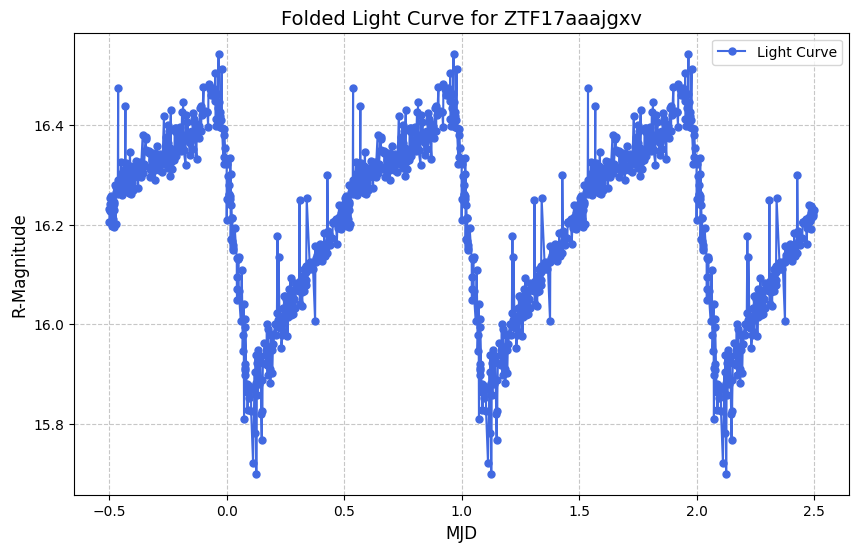

In [ ]:
# 折叠光变曲线
folded_lc = lc.fold(period) 
tim, flx = folded_lc.time.value, folded_lc.flux

# 直接计算相位，避免多次复制数组
phase = tim / period
phase_extended = np.concatenate([phase, phase + 1, phase + 2])
flux_extended = np.tile(flx, 3)

# 创建图形和坐标轴
plt.figure(figsize=(10, 6))

# 绘制光变曲线，点线结合
plt.plot(phase_extended, flux_extended, marker='o', linestyle='-', color='#4169E1', markersize=5, label='Light Curve')

    # 设置坐标轴标签和标题
plt.ylabel('R-Magnitude', fontsize=12)
plt.xlabel('MJD', fontsize=12)
plt.title(f"Folded Light Curve for {df['#oid'][0]}", fontsize=14)

# 设置坐标轴刻度字体大小
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 显示图例
plt.legend(fontsize=10)

# 显示网格线，调整网格线样式
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [2]:
df1 = pd.read_csv("../data/lightcurve_data.csv")
df1

,#oid,period,num_peaks,classALeRCE,time,flux
0,ZTF17aaajgxv,0.572800,51,RRL,"[-0.49942539630433186,-0.49918716586016976,-0....","[16.2058,16.230549,16.24141,16.228073,16.25341..."
1,ZTF17aaarvft,0.197982,66,E,"[-0.49831909833542476,-0.4950773002986282,-0.4...","[12.872672,12.940971,12.945449,12.873761,12.93..."
2,ZTF17aaawecj,0.141549,103,E,"[-0.4996000632531625,-0.4980442585526325,-0.49...","[13.562298,13.590104,13.516534,13.565137,13.53..."
3,ZTF17aabtkpv,0.107327,15260,E,"[-0.47071936453611307,-0.4532932862046125,-0.4...","[16.139889,16.067142,16.121937,16.076378,16.14..."
4,ZTF18aaaizue,0.144033,9377,E,"[-0.3001003371370297,-0.15528214925408973,-0.1...","[15.642073,15.522387,15.527321,15.503612,15.50..."
...,...,...,...,...,...,...
24117,ZTF18aagtegs,1.585586,16177,RRL,"[-0.2745796755985033,-0.25674274157658544,-0.2...","[14.399929,14.242908,14.279523,14.247854,14.29..."
24118,ZTF18aaiyukf,0.510409,3840,RRL,"[-0.4617179422863674,-0.3865598430620424,-0.37...","[16.29467,16.34544,16.29759,16.27945,16.321072..."
24119,ZTF18aapaquz,0.405867,249,RRL,"[-0.499787603836453,-0.4992437168799542,-0.498...","[14.645777,14.654092,14.665266,14.652166,14.74..."
24120,ZTF18aavzlgs,1.009966,3975,LPV,"[-0.4355251277636508,-0.4350795681273988,-0.42...","[15.880947,15.856993,15.8699465,15.646793,15.6..."


In [3]:
a = df1['classALeRCE'].values
b = np.unique(a)

In [5]:
print(b)

['AGN' 'Blazar' 'CEP' 'CV/Nova' 'DSCT' 'E' 'LPV' 'Periodic-Other' 'QSO'
 'RRL' 'SLSN' 'SNII' 'SNIa' 'SNIbc' 'YSO']
